In [1]:
from nltk import CFG, ChartParser
from nltk.corpus import brown
from nltk.probability import FreqDist
from random import choice, choices, random as rand_uniform
from collections import Counter
import matplotlib.pyplot as plt
import random
import numpy as np

# Configuration
ZIPF = True  # Use Zipf-like distribution instead of uniform sampling
num_sentences = 5e4

# --- Sentence generation with optional Zipf-like sampling ------------------
def produce(grammar, symbol, word_probs=None):
    words = []
    productions = grammar.productions(lhs=symbol)
    
    # Choose production - use weighted sampling if ZIPF is enabled
    if word_probs and ZIPF and hasattr(symbol, 'symbol') and symbol.symbol() in word_probs:
        # Get only terminal productions (single string on RHS)
        terminal_prods = [(i, p) for i, p in enumerate(productions) 
                          if len(p.rhs()) == 1 and isinstance(p.rhs()[0], str)]
        
        if terminal_prods:
            # Get words and their probabilities
            indices, prods = zip(*terminal_prods)
            words_list = [p.rhs()[0] for p in prods]
            probs = [word_probs[symbol.symbol()].get(w, 0) for w in words_list]
            
            if sum(probs) > 0:
                # Use weighted choice on terminal productions
                chosen_idx = choices(indices, weights=probs)[0]
                production = productions[chosen_idx]
            else:
                production = choice(productions)
        else:
            production = choice(productions)
    else:
        production = choice(productions)
    
    for sym in production.rhs():
        if isinstance(sym, str):
            words.append(sym)
        else:
            words.extend(produce(grammar, sym, word_probs))
    return words

# --- Build Brown-based word lists -----------------------------------------

tagged = brown.tagged_words(tagset='universal')

# Collect words by coarse POS
nouns = [w.lower() for w, t in tagged if t == 'NOUN']
verbs = [w.lower() for w, t in tagged if t == 'VERB']
dets  = [w.lower() for w, t in tagged if t == 'DET']
adjs  = [w.lower() for w, t in tagged if t == 'ADJ']
preps = [w.lower() for w, t in tagged if t == 'ADP']

# Use frequency to pick the most common ones (to keep grammar manageable)
def top_clean(words, n):
    fd = FreqDist(words)
    result = []
    for w, _ in fd.most_common():
        if not w.isalpha() or "'" in w or "\\" in w:
            continue
        result.append(w)
        if len(result) >= n:
            break
    return result

top_nouns = top_clean(nouns, 200)
top_verbs = top_clean(verbs, 100)
top_dets  = top_clean(dets, 30)
top_adjs  = top_clean(adjs, 100)
top_preps = top_clean(preps, 50)

# --- Disambiguate words that appear in multiple categories -----------------

word_to_categories = {}
for w in top_nouns:
    word_to_categories.setdefault(w, []).append('N')
for w in top_verbs:
    word_to_categories.setdefault(w, []).append('V')
for w in top_dets:
    word_to_categories.setdefault(w, []).append('Det')
for w in top_adjs:
    word_to_categories.setdefault(w, []).append('Adj')
for w in top_preps:
    word_to_categories.setdefault(w, []).append('P')

def disambiguate_words(words, cat):
    result = []
    for w in words:
        cats = word_to_categories[w]
        if len(cats) > 1:
            result.append(f"{w}({cat})")
        else:
            result.append(w)
    return result

disambig_nouns = disambiguate_words(top_nouns, 'N')
disambig_verbs = disambiguate_words(top_verbs, 'V')
disambig_dets  = disambiguate_words(top_dets, 'Det')
disambig_adjs  = disambiguate_words(top_adjs, 'Adj')
disambig_preps = disambiguate_words(top_preps, 'P')

# --- Assign Zipf-like probabilities to words -------------------------------

def assign_zipf_probabilities(words):
    """Shuffle words, assign prob 1/2, 1/3, 1/4, ..., then normalize"""
    shuffled = words.copy()
    random.shuffle(shuffled)
    
    # Assign 1/(rank+1) probabilities
    raw_probs = [1.0 / (i + 2) for i in range(len(shuffled))]
    
    # Normalize
    total = sum(raw_probs)
    normalized_probs = [p / total for p in raw_probs]
    
    return dict(zip(shuffled, normalized_probs))

if ZIPF:
    word_probs = {
        'N': assign_zipf_probabilities(disambig_nouns),
        'V': assign_zipf_probabilities(disambig_verbs),
        'Det': assign_zipf_probabilities(disambig_dets),
        'Adj': assign_zipf_probabilities(disambig_adjs),
        'P': assign_zipf_probabilities(disambig_preps),
    }
else:
    word_probs = None

def make_lexical_rules(lhs, words):
    rules = []
    for w in words:
        rules.append(f"{lhs} -> '{w}'")
    return rules

noun_rules = make_lexical_rules("N", disambig_nouns)
verb_rules = make_lexical_rules("V", disambig_verbs)
det_rules  = make_lexical_rules("Det", disambig_dets)
adj_rules  = make_lexical_rules("Adj", disambig_adjs)
prep_rules = make_lexical_rules("P", disambig_preps)

# Map disambiguated word -> POS category (for counting later)
word2cats = {}
def add_mapping(words, cat):
    for w in words:
        word2cats.setdefault(w, set()).add(cat)

add_mapping(disambig_nouns, 'N')
add_mapping(disambig_verbs, 'V')
add_mapping(disambig_dets,  'Det')
add_mapping(disambig_adjs,  'Adj')
add_mapping(disambig_preps, 'P')

# --- Base grammar skeleton (with adjectives) -------------------------------

base_grammar = """
S -> NP VP
PP -> P NP
NP -> Det N | Det Adj N | Det N PP | Det Adj N PP | 'I'
VP -> V NP | VP PP
"""

# Add Brown-derived lexical rules
full_grammar_str = (
    base_grammar
    + "\n"
    + "\n".join(noun_rules + verb_rules + det_rules + adj_rules + prep_rules)
)

grammar = CFG.fromstring(full_grammar_str)
parser = ChartParser(grammar)

20 EXAMPLE SENTENCES
 1. any only cost become some type though I
 2. them short miles on his national men seems those children
 3. them low nations on both school on these york across I had each free man including his true peace including I
 4. I think these city around what national figure whether our matter than I including his new matter among his general nations
 5. that(Det) nations look those hands because I
 6. thy economic nations that(P) your figure looked what new nations
 7. I be our months because our short town whether I
 8. those others get your job on your nations
 9. your much values than that(Det) certain hours upon I feel no attention until your thing under I
10. those new name had some dead america in those complete nations on his own name on I including those big name including I than some own miles during I like(P) them college
11. the town as that(Det) department seems them new eyes under thy greater nature up I
12. I were another area across each job on that(Det)

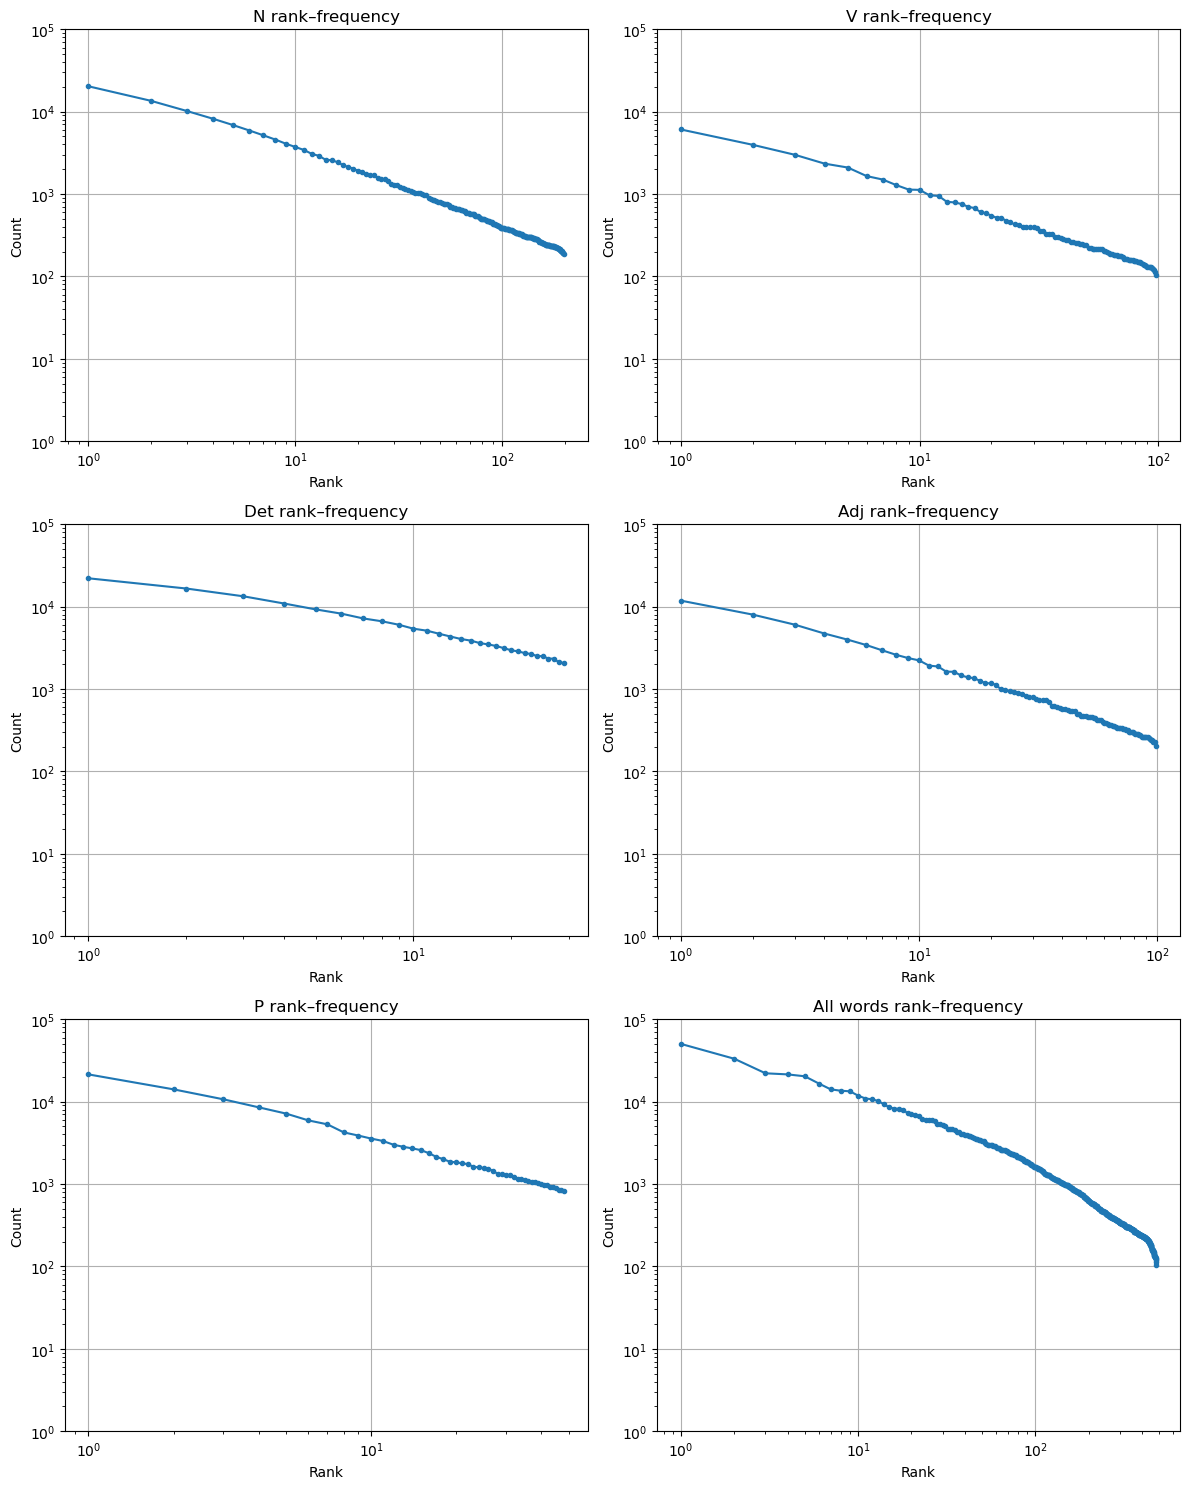